# Health Condition Risk Prediction — End-to-End Classical ML Pipeline

**Objective.** Predict an individual's `health_condition` (`fit`, `at-risk`, `unhealthy`) from
lifestyle, physiological and behavioural attributes (sleep, heart rate, BMI, diet, activity,
stress, etc.), using a fully classical machine-learning stack (no deep learning).

**Scope of this notebook**

1. Data loading, integrity checks and memory profiling
2. Data quality assessment — missingness, duplicates, outliers, range sanity checks
3. Exploratory data analysis (univariate, bivariate, correlation)
4. Statistical hypothesis testing — one-way ANOVA / Kruskal-Wallis (numeric features) and
   Chi-square tests of independence (categorical features), with effect sizes and multiple-testing
   correction
5. Feature engineering, informed by the statistical findings
6. Train / validation / held-out test design
7. Preprocessing pipeline (imputation, scaling, encoding)
8. Baseline model screening via cross-validation (6 classical algorithms)
9. Hyperparameter tuning of the strongest candidate
10. Final model fit on the full training data and evaluation on an untouched held-out test set
11. Model interpretation (native + permutation importance) and error analysis
12. Artifact persistence and conclusions

**A note on class imbalance.** The target is heavily imbalanced (roughly 86% / 8% / 6% across
`at-risk` / `unhealthy` / `fit`). Every modelling and evaluation choice below — class-weighting,
macro-averaged metrics, stratified sampling — is made with this imbalance in mind, since the
minority classes (`fit`, `unhealthy`) are the ones a health-risk system needs to identify reliably.

**A note on compute strategy.** The raw table has ~690K rows. Iterating over 6 candidate models
and a hyperparameter search on the full data at every step would be wasteful. We instead **screen
and tune on a stratified development subsample**, then **refit the winning configuration on the
full training split** and evaluate it once on a held-out test set that no modelling decision has
seen. This is a standard way to keep iteration fast without compromising the final, reported
numbers.

## 1. Environment & Imports

In [1]:
import warnings
import gc

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder, LabelEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)
from sklearn.inspection import permutation_importance

import joblib

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="deep")
PALETTE = {"fit": "#2a9d8f", "at-risk": "#e9c46a", "unhealthy": "#e76f51"}
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

%matplotlib inline

## 2. Data Loading & Initial Inspection

We load the raw CSV, confirm the key column (`id`) is a unique row identifier (not a feature),
and profile memory usage so that dtype optimisation later on is measurable.

In [2]:
RAW_PATH = "train.csv"
df_raw = pd.read_csv(RAW_PATH)
print(f"Rows: {df_raw.shape[0]:,}  |  Columns: {df_raw.shape[1]}")
df_raw.head()

Rows: 690,088  |  Columns: 15


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.2200,70.6000,25.6600,"2,174.0000","1,326.0000",19.8000,1.8600,veg,high,average,sedentary,yes,female
1,1,at-risk,5.5300,71.3000,25.8400,"1,966.0000","9,891.0000",49.9000,1.2600,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.2900,75.4000,24.5400,"2,688.0000","14,216.0000",38.1000,1.6000,veg,high,poor,active,yes,male
3,3,unhealthy,4.7000,77.2000,23.1300,"2,630.0000","7,174.0000",59.9000,2.0200,veg,high,average,active,occasional,female
4,4,at-risk,7.2300,73.4000,28.4400,"2,560.0000","6,584.0000",46.0000,2.2500,veg,NaN,average,sedentary,NaN,male


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  object 
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

In [4]:
assert df_raw["id"].is_unique, "id column is not a unique row identifier"
print("Fully duplicated rows:", df_raw.duplicated().sum())

mem_before = df_raw.memory_usage(deep=True).sum() / 1e6
print(f"Memory footprint (raw dtypes): {mem_before:,.1f} MB")

Fully duplicated rows: 0


Memory footprint (raw dtypes): 303.3 MB


In [5]:
# Dtype optimisation: object columns with a handful of repeated values become `category`
# (compact integer codes instead of Python string objects); numeric columns are downcast to
# float32, which is ample precision for these physiological measurements. This keeps the full
# 690K-row frame cheap to carry through EDA and statistical testing.
TARGET = "health_condition"
NUM_COLS = ["sleep_duration", "heart_rate", "bmi", "calorie_expenditure",
            "step_count", "exercise_duration", "water_intake"]
CAT_COLS = ["diet_type", "stress_level", "sleep_quality",
            "physical_activity_level", "smoking_alcohol", "gender"]

df = df_raw.drop(columns=["id"]).copy()
del df_raw
gc.collect()

df[TARGET] = df[TARGET].astype("category")
for c in CAT_COLS:
    df[c] = df[c].astype("category")
for c in NUM_COLS:
    df[c] = df[c].astype("float32")

mem_after = df.memory_usage(deep=True).sum() / 1e6
print(f"Memory footprint (optimised dtypes): {mem_after:,.1f} MB  "
      f"({mem_after / mem_before:.1%} of original)")
df.dtypes

Memory footprint (optimised dtypes): 24.2 MB  (8.0% of original)


health_condition           category
sleep_duration              float32
heart_rate                  float32
bmi                         float32
calorie_expenditure         float32
step_count                  float32
exercise_duration           float32
water_intake                float32
diet_type                  category
stress_level               category
sleep_quality              category
physical_activity_level    category
smoking_alcohol            category
gender                     category
dtype: object

## 3. Data Quality Assessment

Before any modelling, we quantify *how much* data is missing, *whether missingness itself carries
signal*, and *how many extreme values* each numeric feature has. These findings directly motivate
choices made later in Feature Engineering (Section 6) and Preprocessing (Section 8).

### 3.1 Missing values

In [6]:
missing_summary = (
    df.isnull().sum().to_frame("missing_count")
    .assign(missing_pct=lambda d: d["missing_count"] / len(df) * 100)
    .query("missing_count > 0")
    .sort_values("missing_pct", ascending=False)
)
missing_summary

,missing_count,missing_pct
stress_level,82811,12.0001
sleep_duration,75999,11.0129
sleep_quality,58331,8.4527
calorie_expenditure,52853,7.6589
water_intake,43477,6.3002
physical_activity_level,36621,5.3067
smoking_alcohol,28582,4.1418
gender,21373,3.0971
step_count,13916,2.0166
bmi,13898,2.0139


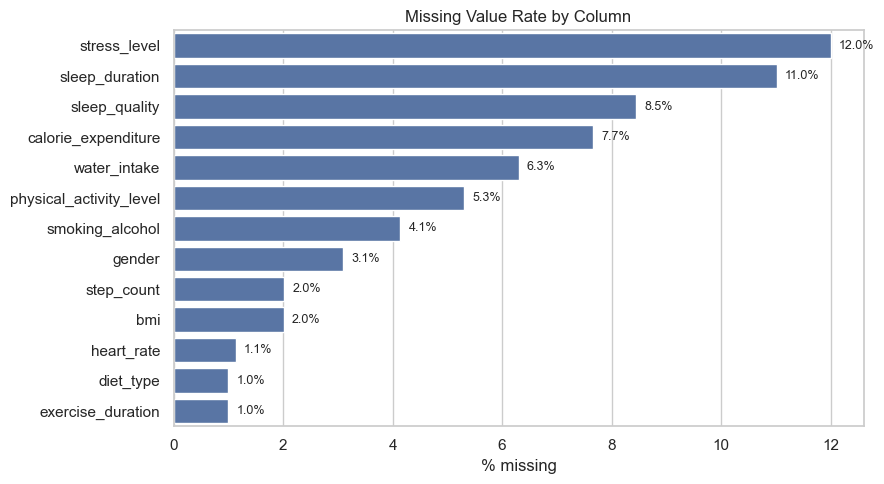

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=missing_summary.reset_index(), x="missing_pct", y="index",
            color="#4c72b0", ax=ax)
ax.set_xlabel("% missing")
ax.set_ylabel("")
ax.set_title("Missing Value Rate by Column")
for i, v in enumerate(missing_summary["missing_pct"]):
    ax.text(v + 0.15, i, f"{v:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

No column exceeds ~12% missingness, and no row is fully missing across a feature group, so we
retain all rows and handle missingness via imputation rather than deletion. Section 5.3 formally
tests whether *being* missing on a given column is itself associated with the target — if so, we
encode that as an explicit signal in Section 6.

### 3.2 Outlier screening (IQR rule)

In [8]:
def iqr_outlier_summary(frame, cols):
    rows = []
    for c in cols:
        s = frame[c].dropna()
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = ((s < lo) | (s > hi)).sum()
        rows.append({"feature": c, "q1": q1, "q3": q3, "lower_fence": lo, "upper_fence": hi,
                     "n_outliers": n_out, "pct_outliers": n_out / len(s) * 100})
    return pd.DataFrame(rows).sort_values("pct_outliers", ascending=False).reset_index(drop=True)

outlier_summary = iqr_outlier_summary(df, NUM_COLS)
outlier_summary

,feature,q1,q3,lower_fence,upper_fence,n_outliers,pct_outliers
0,calorie_expenditure,"2,053.0000","2,456.0000","1,448.5000","3,060.5000",12831,2.0135
1,water_intake,1.8400,2.5000,0.8500,3.4900,11194,1.7312
2,bmi,21.3200,24.6600,16.3100,29.6700,5284,0.7814
3,heart_rate,69.4000,80.7000,52.4500,97.6500,2825,0.4141
4,sleep_duration,6.1600,7.8100,3.6850,10.2850,2020,0.3289
5,exercise_duration,29.2000,49.4000,-1.1000,79.7000,104,0.0152
6,step_count,"5,389.0000","12,114.0000","-4,698.5000","22,201.5000",0,0.0000


Outlier prevalence is low to moderate across the board (Tukey's 1.5×IQR rule is conservative and
routinely flags several percent of points even in clean, unimodal data). Rather than discarding
these rows — which could disproportionately remove genuine high-risk or high-fitness individuals,
exactly the minority classes we care about — we use **RobustScaler** (median / IQR based) in the
preprocessing pipeline in Section 8, so scaling is not distorted by tail values without losing them.

### 3.3 Range sanity checks

In [9]:
df[NUM_COLS].describe().T.assign(
    skew=df[NUM_COLS].skew(),
    kurtosis=df[NUM_COLS].kurtosis()
)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
sleep_duration,"614,089.0000",6.9926,1.2154,3.0000,6.1600,6.9900,7.8100,10.0000,-0.0082,-0.1145
heart_rate,"682,255.0000",75.0965,8.1751,50.0000,69.4000,75.1000,80.7000,107.7000,0.0004,-0.1867
bmi,"676,190.0000",22.9849,2.4818,16.0000,21.3200,22.9900,24.6600,34.8200,0.0246,-0.0281
calorie_expenditure,"637,235.0000","2,226.0850",347.5321,"1,200.0000","2,053.0000","2,241.0000","2,456.0000","3,580.0000",-0.1839,-0.0626
step_count,"676,172.0000","8,615.9531","3,929.3999","1,002.0000","5,389.0000","8,856.0000","12,114.0000","14,999.0000",-0.1802,-1.1149
exercise_duration,"683,187.0000",38.7515,14.7422,0.0000,29.2000,39.4000,49.4000,99.8000,-0.3746,0.0347
water_intake,"646,611.0000",2.1885,0.5185,0.5000,1.8400,2.1700,2.5000,4.7200,0.1100,0.4943


All ranges are physiologically plausible (e.g. resting/active heart rate 50–108 bpm, BMI 16–34.8,
sleep 3–10 hours) — there is no evidence of unit errors or corrupted sentinel values (e.g. `-1`,
`999`), so no clipping is required at this stage.

## 4. Exploratory Data Analysis

### 4.1 Target distribution

In [10]:
target_counts = df[TARGET].value_counts()
target_pct = df[TARGET].value_counts(normalize=True) * 100
target_summary = pd.DataFrame({"count": target_counts, "pct": target_pct})
target_summary

,count,pct
health_condition,,
at-risk,592561,85.8675
unhealthy,57724,8.3647
fit,39803,5.7678


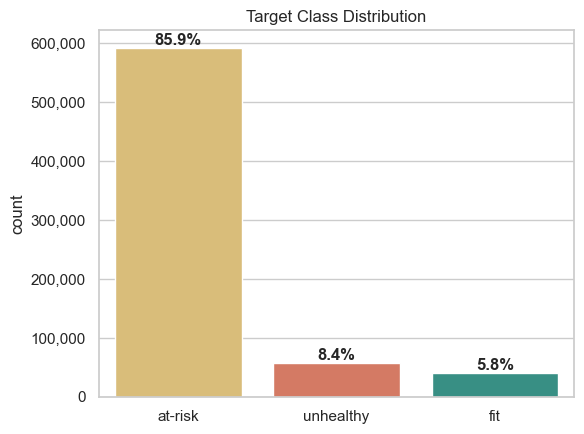

In [11]:
fig, ax = plt.subplots(figsize=(6, 4.5))
order = target_summary.index
sns.countplot(data=df, x=TARGET, order=order, palette=PALETTE, ax=ax)
for i, cls in enumerate(order):
    ax.text(i, target_counts[cls] + 5000, f"{target_pct[cls]:.1f}%", ha="center", fontweight="bold")
ax.set_title("Target Class Distribution")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

The classes are markedly imbalanced (~86% `at-risk`, ~8% `unhealthy`, ~6% `fit`). This has two
concrete consequences for everything downstream: (1) plain accuracy is a poor model-selection
metric here, since a model that always predicts `at-risk` would score ~86% while being clinically
useless — we use **macro-averaged F1 / balanced accuracy** instead; and (2) we use
**class-weighted** estimators so minority classes are not drowned out during training.

### 4.2 Numeric feature distributions

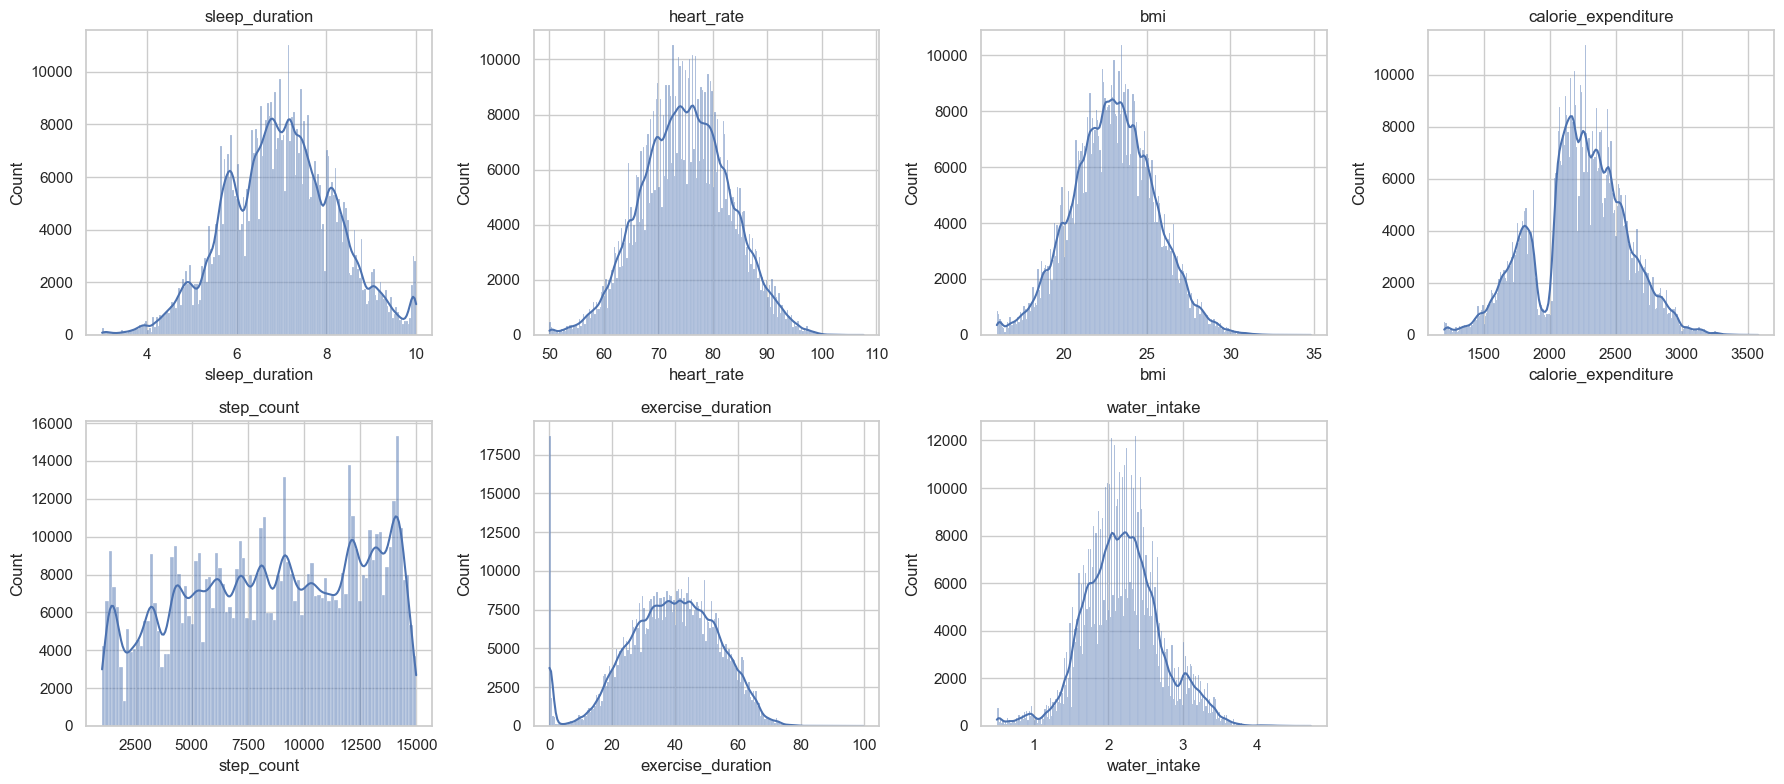

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, c in enumerate(NUM_COLS):
    sns.histplot(df[c].dropna(), kde=True, ax=axes[i], color="#4c72b0")
    axes[i].set_title(c)
axes[-1].axis("off")
plt.tight_layout()
plt.show()

### 4.3 Categorical feature distributions

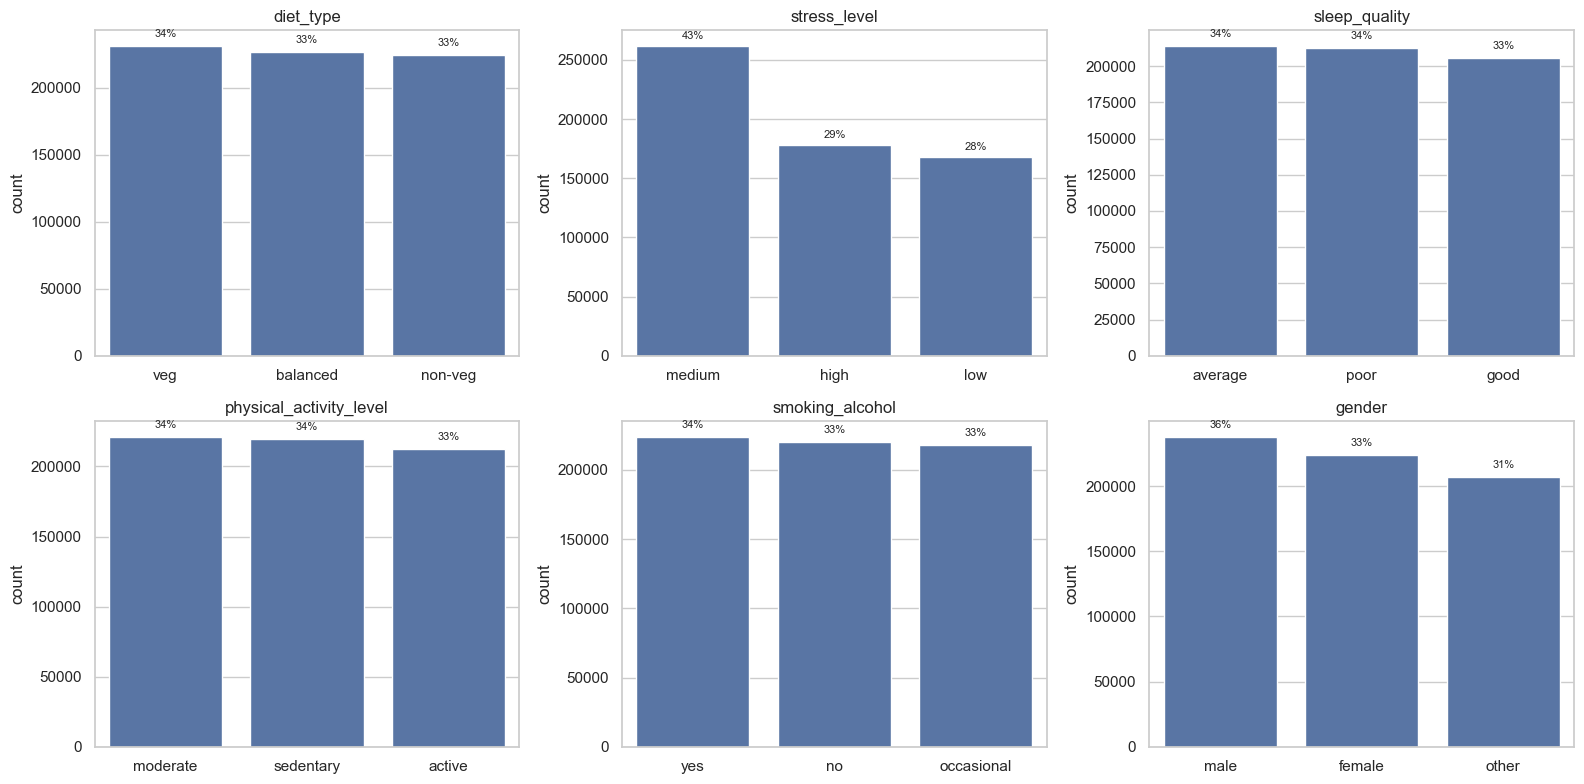

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, c in enumerate(CAT_COLS):
    col_order = df[c].value_counts().index
    sns.countplot(data=df, x=c, order=col_order, color="#4c72b0", ax=axes[i])
    total = df[c].notna().sum()
    for p in axes[i].patches:
        h = p.get_height()
        axes[i].text(p.get_x() + p.get_width() / 2, h + total * 0.01,
                     f"{h / total * 100:.0f}%", ha="center", fontsize=8)
    axes[i].set_title(c)
    axes[i].set_xlabel("")
plt.tight_layout()
plt.show()

### 4.4 Numeric features vs. target

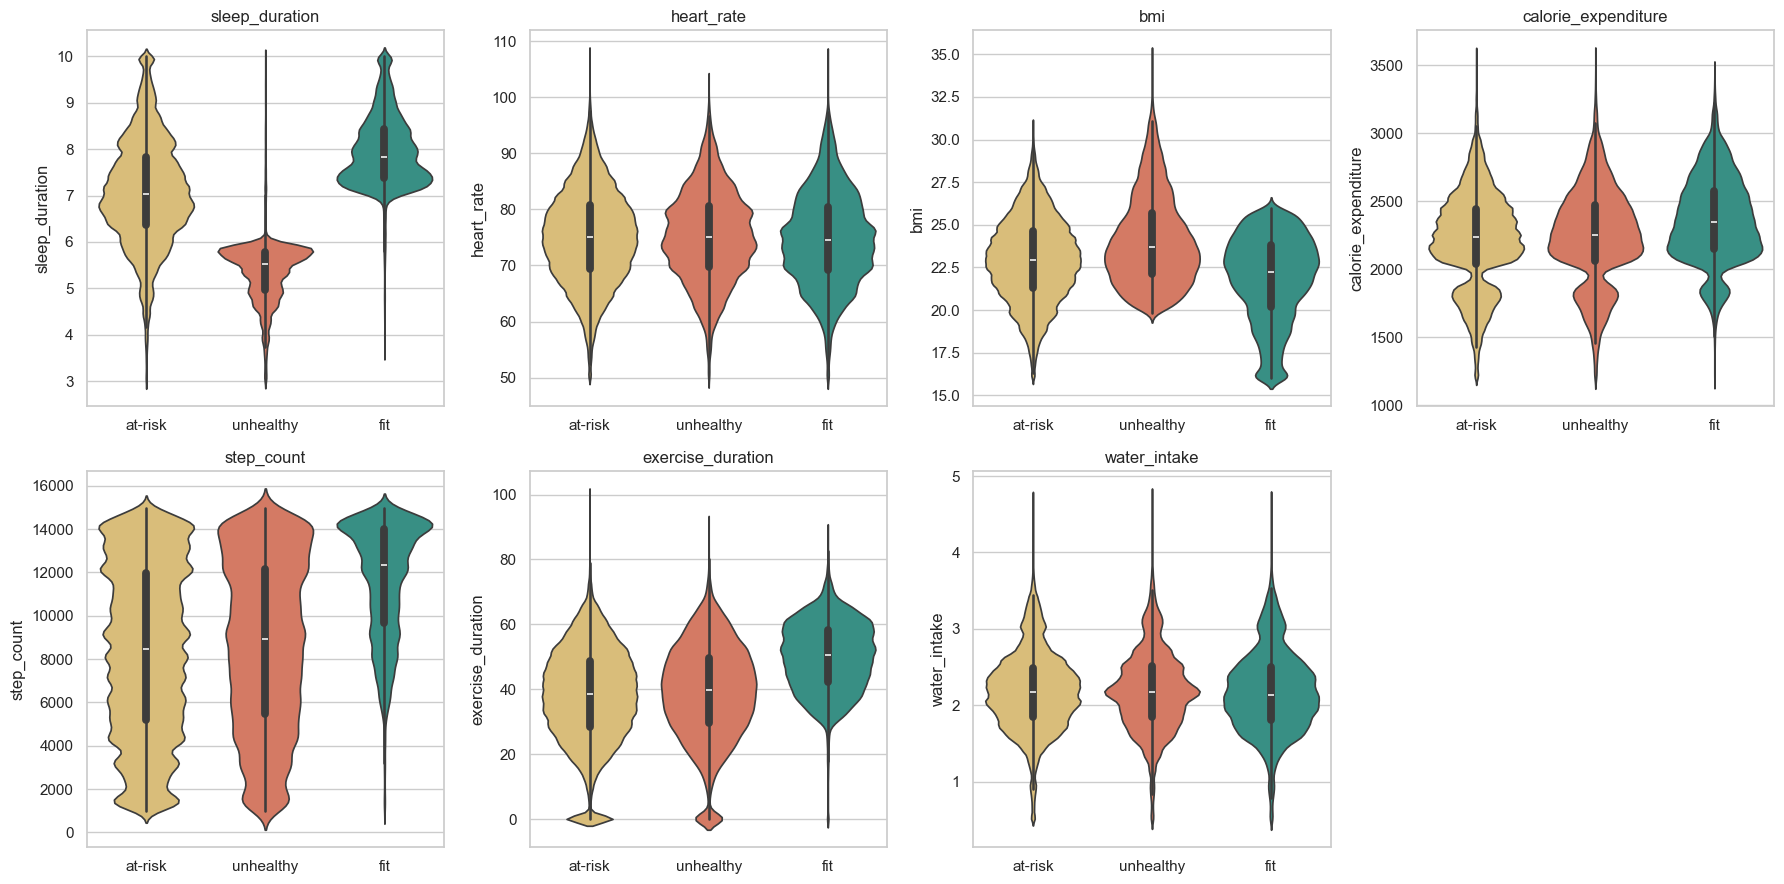

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for i, c in enumerate(NUM_COLS):
    sns.violinplot(data=df, x=TARGET, y=c, order=order, hue=TARGET,
                   palette=PALETTE, legend=False, ax=axes[i])
    axes[i].set_title(c)
    axes[i].set_xlabel("")
axes[-1].axis("off")
plt.tight_layout()
plt.show()

### 4.5 Categorical features vs. target (row-normalised)

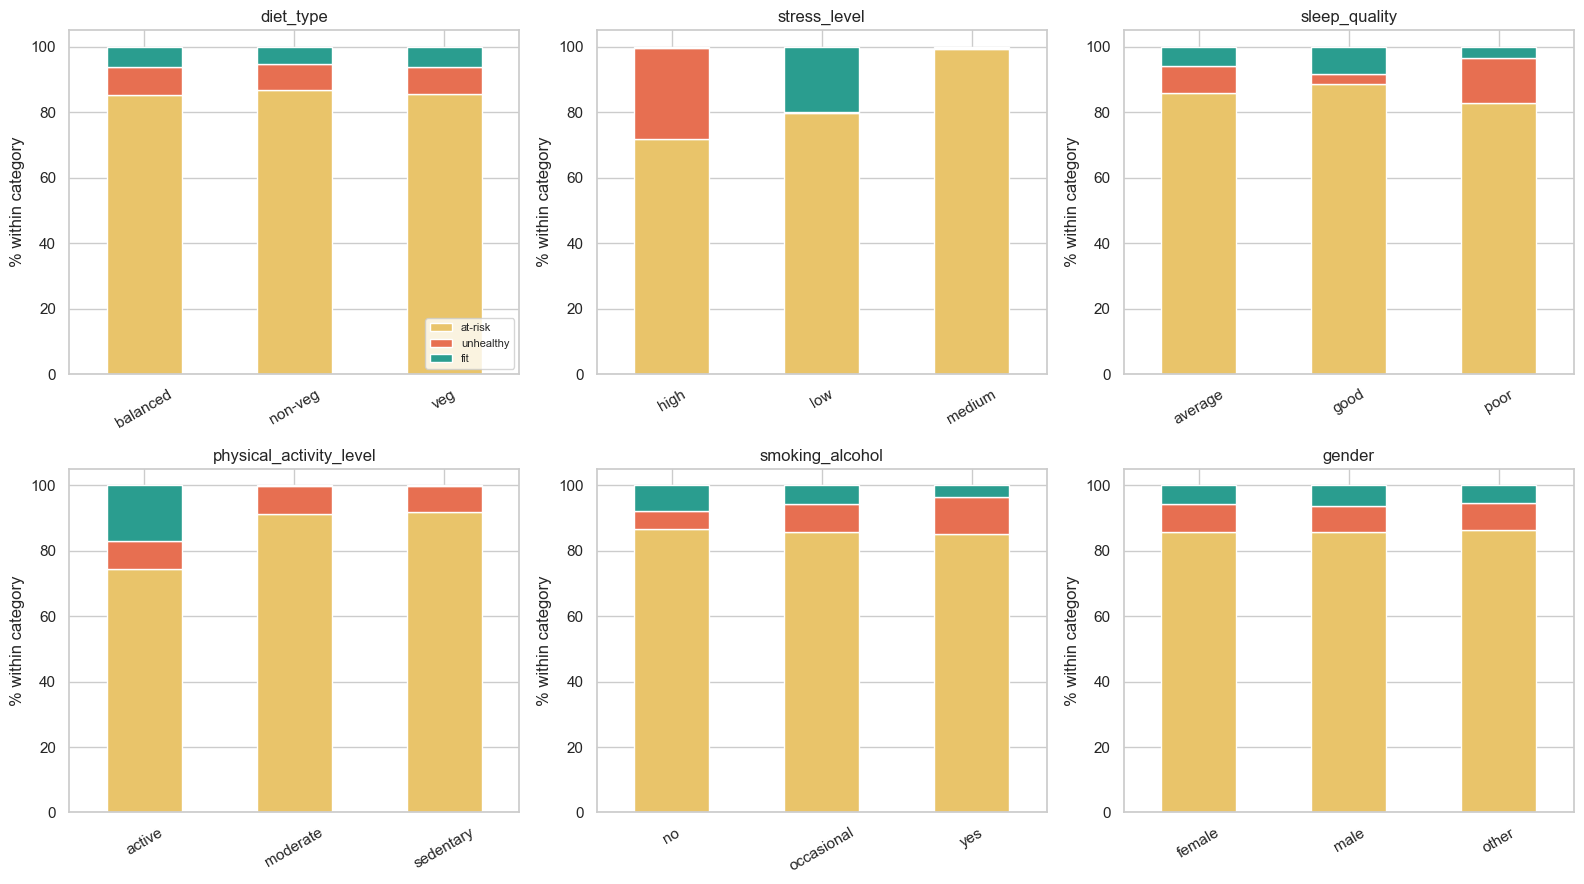

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, c in enumerate(CAT_COLS):
    ct = pd.crosstab(df[c], df[TARGET], normalize="index") * 100
    ct = ct[order]
    ct.plot(kind="bar", stacked=True, color=[PALETTE[cls] for cls in order],
            ax=axes[i], legend=(i == 0))
    axes[i].set_title(c)
    axes[i].set_ylabel("% within category")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=30)
if axes[0].get_legend() is not None:
    axes[0].legend(title="", fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

### 4.6 Correlation structure among numeric features

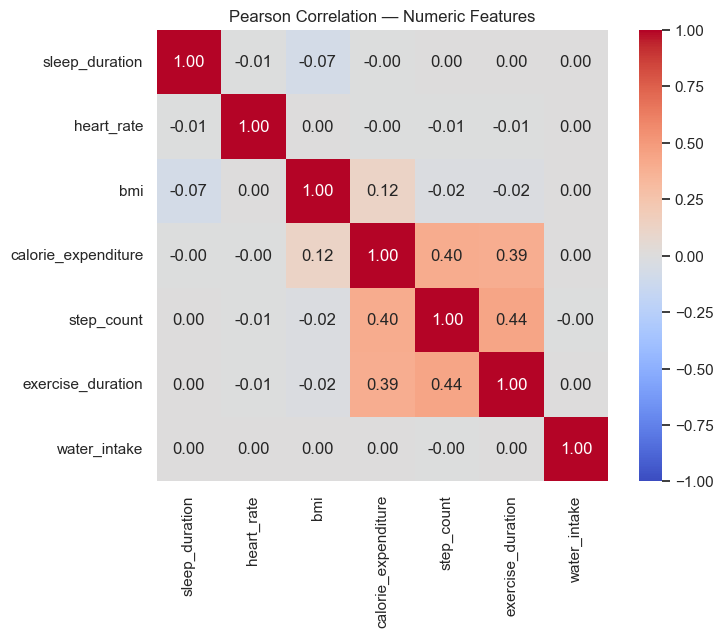

Pairs with |r| > 0.5 (none expected to be problematic for tree models; flagged for awareness with the linear baselines):


,level_0,level_1,r


In [16]:
corr = df[NUM_COLS].corr()
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Pearson Correlation — Numeric Features")
plt.tight_layout()
plt.show()

high_corr = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack().rename("r").reset_index()
    .query("abs(r) > 0.5")
    .sort_values("r", key=abs, ascending=False)
)
print("Pairs with |r| > 0.5 (none expected to be problematic for tree models; "
      "flagged for awareness with the linear baselines):")
high_corr

No pair of raw numeric features is strongly correlated (|r| > 0.5), so multicollinearity is not a
concern for the linear baselines, and every raw feature carries largely independent information.

## 5. Statistical Hypothesis Testing

EDA plots suggest which features separate the classes, but we back that impression with formal
tests, effect sizes, and multiple-testing correction — this is what actually drives which
engineered features earn a place in the model (Section 6), rather than intuition alone.

We test at &alpha; = 0.05 throughout, and control the false discovery rate across all tests run in
this section with the Benjamini-Hochberg procedure (implemented manually below, since `statsmodels`
is not part of this environment).

In [17]:
def benjamini_hochberg(pvalues):
    p = np.asarray(pvalues, dtype=float)
    n = len(p)
    order = np.argsort(p)
    ranked = p[order]
    adj = ranked * n / (np.arange(1, n + 1))
    adj = np.minimum.accumulate(adj[::-1])[::-1]
    adj = np.clip(adj, 0, 1)
    out = np.empty(n)
    out[order] = adj
    return out

def cramers_v(chi2, contingency_table):
    n = contingency_table.to_numpy().sum()
    r, k = contingency_table.shape
    return np.sqrt((chi2 / n) / (min(r - 1, k - 1)))

def eta_squared(values, groups_series):
    grand_mean = values.mean()
    ss_total = ((values - grand_mean) ** 2).sum()
    ss_between = sum(
        len(g) * (g.mean() - grand_mean) ** 2
        for _, g in values.groupby(groups_series)
    )
    return ss_between / ss_total

### 5.1 Numeric features vs. target — ANOVA, Kruskal-Wallis & effect sizes

For each numeric feature we run:
- **One-way ANOVA** (`f_oneway`) — the classical parametric test of whether class means differ
- **Levene's test** — checks the equal-variance assumption ANOVA relies on
- **Kruskal-Wallis H-test** — a rank-based, distribution-free alternative that remains valid even
  if ANOVA's assumptions are violated (worth running given the class-size imbalance and the mild
  skew seen in Section 3.3)
- **&eta;&sup2; (eta-squared)** — effect size: the *proportion of variance explained* by class
  membership, which is what actually tells us whether a statistically significant difference
  (easy to obtain with n≈690K) is also a *practically meaningful* one

In [18]:
anova_rows = []
for c in NUM_COLS:
    sub = df[[c, TARGET]].dropna()
    groups = [g[c].values for _, g in sub.groupby(TARGET, observed=True)]
    f_stat, anova_p = stats.f_oneway(*groups)
    lev_stat, lev_p = stats.levene(*groups)
    kw_stat, kw_p = stats.kruskal(*groups)
    eta_sq = eta_squared(sub[c], sub[TARGET])
    anova_rows.append({
        "feature": c, "anova_F": f_stat, "anova_p": anova_p,
        "levene_p": lev_p, "kruskal_H": kw_stat, "kruskal_p": kw_p,
        "eta_squared": eta_sq
    })

numeric_stats_df = pd.DataFrame(anova_rows)
numeric_stats_df["anova_p_adj"] = benjamini_hochberg(numeric_stats_df["anova_p"])
numeric_stats_df["kruskal_p_adj"] = benjamini_hochberg(numeric_stats_df["kruskal_p"])
numeric_stats_df["significant"] = (numeric_stats_df["anova_p_adj"] < 0.05) & (numeric_stats_df["kruskal_p_adj"] < 0.05)
numeric_stats_df = numeric_stats_df.sort_values("eta_squared", ascending=False).reset_index(drop=True)
numeric_stats_df[["feature", "anova_F", "anova_p_adj", "levene_p", "kruskal_p_adj", "eta_squared", "significant"]]

,feature,anova_F,anova_p_adj,levene_p,kruskal_p_adj,eta_squared,significant
0,sleep_duration,"72,549.6562",0.0000,0.0000,0.0000,0.1911,True
1,step_count,"12,944.7725",0.0000,0.0000,0.0000,0.0369,True
2,exercise_duration,"12,865.1143",0.0000,0.0000,0.0000,0.0363,True
3,bmi,"10,601.0898",0.0000,0.0000,0.0000,0.0304,True
4,calorie_expenditure,"3,289.7578",0.0000,0.0000,0.0000,0.0102,True
5,heart_rate,36.3194,0.0000,0.0000,0.0000,0.0001,True
6,water_intake,6.4575,0.0016,0.0000,0.0000,0.0000,True


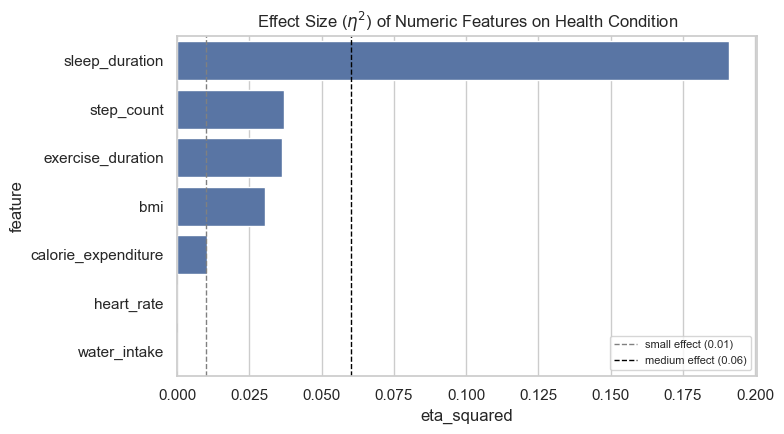

In [19]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=numeric_stats_df, x="eta_squared", y="feature", color="#4c72b0", ax=ax)
ax.axvline(0.01, color="grey", ls="--", lw=1, label="small effect (0.01)")
ax.axvline(0.06, color="black", ls="--", lw=1, label="medium effect (0.06)")
ax.set_title(r"Effect Size ($\eta^2$) of Numeric Features on Health Condition")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 5.2 Categorical features vs. target — Chi-square test of independence & Cramer's V

In [20]:
chi2_rows = []
for c in CAT_COLS:
    ct = pd.crosstab(df[c], df[TARGET])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    v = cramers_v(chi2, ct)
    chi2_rows.append({"feature": c, "chi2": chi2, "dof": dof, "p_value": p, "cramers_v": v})

chi2_df = pd.DataFrame(chi2_rows)
chi2_df["p_adj"] = benjamini_hochberg(chi2_df["p_value"])
chi2_df["significant"] = chi2_df["p_adj"] < 0.05
chi2_df = chi2_df.sort_values("cramers_v", ascending=False).reset_index(drop=True)
chi2_df

,feature,chi2,dof,p_value,cramers_v,p_adj,significant
0,stress_level,"206,618.5215",4,0.0000,0.4125,0.0000,True
1,physical_activity_level,"75,816.2347",4,0.0000,0.2409,0.0000,True
2,sleep_quality,"18,269.8313",4,0.0000,0.1202,0.0000,True
3,smoking_alcohol,"7,715.6995",4,0.0000,0.0764,0.0000,True
4,diet_type,323.1108,4,0.0000,0.0154,0.0000,True
5,gender,227.8167,4,0.0000,0.0131,0.0000,True


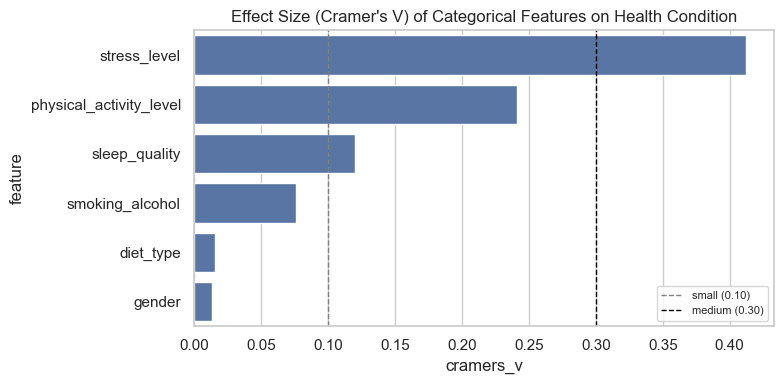

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=chi2_df, x="cramers_v", y="feature", color="#4c72b0", ax=ax)
ax.axvline(0.10, color="grey", ls="--", lw=1, label="small (0.10)")
ax.axvline(0.30, color="black", ls="--", lw=1, label="medium (0.30)")
ax.set_title("Effect Size (Cramer's V) of Categorical Features on Health Condition")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 5.3 Is missingness itself informative?

If a column is missing *not at random* — e.g. more likely to be missing for `unhealthy`
individuals — that missingness pattern is a feature in its own right. We test each column that has
>3% missing values with a chi-square test between a binary "is missing" indicator and the target.

In [22]:
candidate_missing_cols = missing_summary.query("missing_pct > 3").index.tolist()

missingness_rows = []
for c in candidate_missing_cols:
    indicator = df[c].isnull()
    ct = pd.crosstab(indicator, df[TARGET])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    v = cramers_v(chi2, ct)
    missingness_rows.append({"feature": c, "missing_pct": missing_summary.loc[c, "missing_pct"],
                              "chi2": chi2, "p_value": p, "cramers_v": v})

missingness_assoc_df = pd.DataFrame(missingness_rows)
missingness_assoc_df["p_adj"] = benjamini_hochberg(missingness_assoc_df["p_value"])
missingness_assoc_df["informative"] = (missingness_assoc_df["p_adj"] < 0.05) & (missingness_assoc_df["cramers_v"] > 0.01)
missingness_assoc_df = missingness_assoc_df.sort_values("cramers_v", ascending=False).reset_index(drop=True)
missingness_assoc_df

,feature,missing_pct,chi2,p_value,cramers_v,p_adj,informative
0,water_intake,6.3002,6.4972,0.0388,0.0031,0.3106,False
1,gender,3.0971,3.0478,0.2179,0.0021,0.8714,False
2,sleep_quality,8.4527,1.9778,0.3720,0.0017,0.9590,False
3,smoking_alcohol,4.1418,1.4039,0.4956,0.0014,0.9590,False
4,sleep_duration,11.0129,0.3224,0.8511,0.0007,0.9590,False
5,physical_activity_level,5.3067,0.2100,0.9003,0.0006,0.9590,False
6,calorie_expenditure,7.6589,0.1947,0.9073,0.0005,0.9590,False
7,stress_level,12.0001,0.0838,0.9590,0.0003,0.9590,False


In [23]:
INFORMATIVE_MISSING_COLS = missingness_assoc_df.query("informative").feature.tolist()
print("Columns whose missingness pattern is statistically associated with the target:")
print(INFORMATIVE_MISSING_COLS if INFORMATIVE_MISSING_COLS else "(none cleared the significance + effect-size bar)")

Columns whose missingness pattern is statistically associated with the target:
(none cleared the significance + effect-size bar)


### 5.4 Statistical findings — summary

In [24]:
print("Top numeric drivers (by eta-squared):")
display(numeric_stats_df[["feature", "eta_squared", "anova_p_adj"]].head(5))
print()
print("Top categorical drivers (by Cramer's V):")
display(chi2_df[["feature", "cramers_v", "p_adj"]].head(5))

Top numeric drivers (by eta-squared):


,feature,eta_squared,anova_p_adj
0,sleep_duration,0.1911,0.0000
1,step_count,0.0369,0.0000
2,exercise_duration,0.0363,0.0000
3,bmi,0.0304,0.0000
4,calorie_expenditure,0.0102,0.0000



Top categorical drivers (by Cramer's V):


,feature,cramers_v,p_adj
0,stress_level,0.4125,0.0000
1,physical_activity_level,0.2409,0.0000
2,sleep_quality,0.1202,0.0000
3,smoking_alcohol,0.0764,0.0000
4,diet_type,0.0154,0.0000


**Reading the results.** With n ≈ 690K, ANOVA/Chi-square p-values are extremely small for almost
every feature — statistical significance alone is not discriminating at this sample size. The
effect sizes (&eta;&sup2;, Cramer's V) are what we actually rely on to rank features, and the
Kruskal-Wallis / Levene checks confirm the ANOVA conclusions are not artefacts of unequal variances
or skew. Features with the largest effect sizes above are the ones the engineered features in
Section 6 are built around, and the ones we expect to dominate the model's feature-importance
ranking in Section 12 — that agreement is a useful sanity check on the whole pipeline.

## 6. Feature Engineering

Guided by Section 5, we add:

- **Physiologically-motivated ratios** that combine raw signals the way a clinician would read
  them jointly rather than in isolation (e.g. calories burned *per step*, rather than either alone)
- **`bmi_category`** — the standard WHO BMI bands, since health risk is known to be non-linear in
  raw BMI (both under- and over-weight carry risk, a pattern a linear model cannot see in the raw
  number but a binned category exposes directly)
- **Missing-value indicators** for the columns Section 5.3 flagged as informatively missing —
  carrying the "was this ever recorded?" signal forward instead of discarding it at imputation time

All of these are computed row-wise from raw inputs only, so they introduce no leakage across rows
and can be safely applied identically to train and test data.

In [25]:
def engineer_features(data):
    data = data.copy()
    data["calorie_per_step"] = data["calorie_expenditure"] / (data["step_count"] + 1)
    data["activity_score"] = data["step_count"] * data["exercise_duration"]
    data["water_per_bmi"] = data["water_intake"] / data["bmi"]
    data["heart_rate_bmi_ratio"] = data["heart_rate"] / data["bmi"]
    data["sleep_exercise_ratio"] = data["sleep_duration"] / (data["exercise_duration"] + 1)
    data["calorie_per_bmi"] = data["calorie_expenditure"] / data["bmi"]
    data["bmi_category"] = pd.cut(
        data["bmi"], bins=[0, 18.5, 25, 30, 100],
        labels=["underweight", "normal", "overweight", "obese"]
    )
    for c in INFORMATIVE_MISSING_COLS:
        data[f"{c}_missing"] = data[c].isnull().astype("int8")
    return data

df_fe = engineer_features(df)

ENGINEERED_NUM_COLS = NUM_COLS + ["calorie_per_step", "activity_score", "water_per_bmi",
                                   "heart_rate_bmi_ratio", "sleep_exercise_ratio", "calorie_per_bmi"]
ENGINEERED_CAT_COLS = CAT_COLS + ["bmi_category"]
MISSING_INDICATOR_COLS = [f"{c}_missing" for c in INFORMATIVE_MISSING_COLS]
FEATURE_COLS = ENGINEERED_NUM_COLS + ENGINEERED_CAT_COLS + MISSING_INDICATOR_COLS

print(f"{len(FEATURE_COLS)} model features: "
      f"{len(ENGINEERED_NUM_COLS)} numeric, {len(ENGINEERED_CAT_COLS)} categorical, "
      f"{len(MISSING_INDICATOR_COLS)} missing-indicator")
df_fe[FEATURE_COLS].head()

20 model features: 13 numeric, 7 categorical, 0 missing-indicator


,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,calorie_per_step,activity_score,water_per_bmi,heart_rate_bmi_ratio,sleep_exercise_ratio,calorie_per_bmi,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender,bmi_category
0,5.2200,70.6000,25.6600,"2,174.0000","1,326.0000",19.8000,1.8600,1.6383,"26,254.7988",0.0725,2.7514,0.2510,84.7233,veg,high,average,sedentary,yes,female,overweight
1,5.5300,71.3000,25.8400,"1,966.0000","9,891.0000",49.9000,1.2600,0.1987,"493,560.9062",0.0488,2.7593,0.1086,76.0836,non-veg,low,average,moderate,yes,other,overweight
2,5.2900,75.4000,24.5400,"2,688.0000","14,216.0000",38.1000,1.6000,0.1891,"541,629.5625",0.0652,3.0725,0.1353,109.5354,veg,high,poor,active,yes,male,normal
3,4.7000,77.2000,23.1300,"2,630.0000","7,174.0000",59.9000,2.0200,0.3666,"429,722.6250",0.0873,3.3377,0.0772,113.7051,veg,high,average,active,occasional,female,normal
4,7.2300,73.4000,28.4400,"2,560.0000","6,584.0000",46.0000,2.2500,0.3888,"302,864.0000",0.0791,2.5809,0.1538,90.0141,veg,NaN,average,sedentary,NaN,male,overweight


In [26]:
df_fe[ENGINEERED_NUM_COLS].isnull().sum().to_frame("n_missing").assign(
    pct_missing=lambda d: d["n_missing"] / len(df_fe) * 100
)

,n_missing,pct_missing
sleep_duration,75999,11.0129
heart_rate,7833,1.1351
bmi,13898,2.0139
calorie_expenditure,52853,7.6589
step_count,13916,2.0166
exercise_duration,6901,1.0000
water_intake,43477,6.3002
calorie_per_step,65698,9.5202
activity_score,20686,2.9976
water_per_bmi,56510,8.1888


The engineered ratios inherit missingness from their inputs (e.g. `calorie_per_bmi` is null
whenever either `calorie_expenditure` or `bmi` is), which is expected and handled by the same
median-imputation step as the raw numeric features in Section 8.

## 7. Train / Development / Held-Out Test Design

- **`train_full` / `test_full`** — an 80/20 stratified split of the *entire* engineered dataset.
  `test_full` (~138K rows) is set aside now and touched **exactly once**, at the very end
  (Section 10), for the final reported numbers.
- **`dev`** — a stratified subsample of `train_full` used for model screening (Section 8) and
  hyperparameter search (Section 9), where we need many fast iterations rather than one slow one.
  Stratification preserves the ~86/8/6 class balance at every level so no split accidentally
  starves a minority class.
- The winning configuration is then **refit on the full `train_full`** (not just `dev`) before
  touching `test_full`, so the final model benefits from all the training data we have.

In [27]:
le = LabelEncoder()
df_fe["target_enc"] = le.fit_transform(df_fe[TARGET])
print("Label encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

X_all = df_fe[FEATURE_COLS]
y_all = df_fe["target_enc"].values

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_all, y_all, test_size=0.20, random_state=RANDOM_STATE, stratify=y_all
)

DEV_SAMPLE_SIZE = 120_000
X_dev, _, y_dev, _ = train_test_split(
    X_train_full, y_train_full, train_size=DEV_SAMPLE_SIZE,
    random_state=RANDOM_STATE, stratify=y_train_full
)

print(f"train_full: {X_train_full.shape}   test_full: {X_test_full.shape}   dev: {X_dev.shape}")
print()
for name, y in [("train_full", y_train_full), ("test_full", y_test_full), ("dev", y_dev)]:
    pct = np.bincount(y) / len(y) * 100
    print(f"{name:10s} class balance:", dict(zip(le.classes_, np.round(pct, 2))))

Label encoding: {'at-risk': np.int64(0), 'fit': np.int64(1), 'unhealthy': np.int64(2)}


train_full: (552070, 20)   test_full: (138018, 20)   dev: (120000, 20)

train_full class balance: {'at-risk': np.float64(85.87), 'fit': np.float64(5.77), 'unhealthy': np.float64(8.36)}
test_full  class balance: {'at-risk': np.float64(85.87), 'fit': np.float64(5.77), 'unhealthy': np.float64(8.36)}
dev        class balance: {'at-risk': np.float64(85.87), 'fit': np.float64(5.77), 'unhealthy': np.float64(8.36)}


## 8. Preprocessing Pipeline

- **Numeric features**: median imputation (robust to the mild skew/outliers noted in Section 3),
  then `RobustScaler` (centres on the median, scales by IQR) — this matters most for the linear
  models (`LogisticRegression`, `SGDClassifier`), which are sensitive to feature scale and to
  outliers when `StandardScaler`'s mean/variance would otherwise be pulled around by tail values.
- **Categorical features**: most-frequent imputation, then one-hot encoding
  (`handle_unknown="ignore"` so any unseen category at inference time degrades gracefully to an
  all-zero row instead of raising).
- One shared `ColumnTransformer` is used for every candidate model below, so model comparisons in
  Section 9 isolate the effect of the *algorithm*, not differences in preprocessing.
- We deliberately **do not** apply a hard `SelectFromModel` feature-selection gate: after encoding
  there are only ~30 features, and Section 5 already shows most raw signals carry independent,
  statistically-supported information. At this dimensionality, selection would add compute without
  a clear benefit; we instead inspect feature/permutation importance post-hoc in Section 12.

In [28]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, ENGINEERED_NUM_COLS),
    ("cat", categorical_transformer, ENGINEERED_CAT_COLS + MISSING_INDICATOR_COLS)
])
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## 9. Baseline Model Comparison (Cross-Validated)

Six candidates, all class-weighted where supported, evaluated with 3-fold stratified
cross-validation on `dev`:

- `DummyClassifier` (most-frequent) — the naive floor every model must clear
- `LogisticRegression`, `SGDClassifier` — linear baselines
- `RandomForestClassifier`, `ExtraTreesClassifier` — bagged tree ensembles
- `HistGradientBoostingClassifier` — boosted trees, typically the strongest classical tabular model

We score on **accuracy, balanced accuracy, macro/weighted F1, macro precision/recall, and
weighted ROC-AUC (OVR)** — reporting the full spread, but selecting the winner on **macro F1**,
since it weighs the `fit` and `unhealthy` minority classes as heavily as the dominant `at-risk`
class, unlike accuracy or weighted F1.

In [29]:
candidate_models = {
    "Dummy (most_frequent)": DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE),
    "LogisticRegression": LogisticRegression(max_iter=2000, class_weight="balanced", n_jobs=1),
    "SGDClassifier": SGDClassifier(loss="log_loss", class_weight="balanced", random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(
        n_estimators=200, max_depth=15, class_weight="balanced_subsample",
        random_state=RANDOM_STATE, n_jobs=1
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=200, max_depth=15, class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=1
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        class_weight="balanced", random_state=RANDOM_STATE
    ),
}

SCORING = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "roc_auc_ovr_weighted": "roc_auc_ovr_weighted",
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

In [30]:
cv_records = []
for name, model in candidate_models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", model)])
    cv_res = cross_validate(pipe, X_dev, y_dev, cv=cv, scoring=SCORING, n_jobs=4, error_score="raise")
    record = {"model": name}
    for metric in SCORING:
        record[metric] = cv_res[f"test_{metric}"].mean()
        record[f"{metric}_std"] = cv_res[f"test_{metric}"].std()
    cv_records.append(record)
    print(f"{name:24s} f1_macro={record['f1_macro']:.4f} (+/-{record['f1_macro_std']:.4f})   "
          f"balanced_acc={record['balanced_accuracy']:.4f}   accuracy={record['accuracy']:.4f}")

cv_results_df = pd.DataFrame(cv_records).set_index("model").sort_values("f1_macro", ascending=False)

Dummy (most_frequent)    f1_macro=0.3080 (+/-0.0000)   balanced_acc=0.3333   accuracy=0.8587


LogisticRegression       f1_macro=0.6598 (+/-0.0046)   balanced_acc=0.8601   accuracy=0.7991


SGDClassifier            f1_macro=0.7725 (+/-0.0034)   balanced_acc=0.8350   accuracy=0.9000


RandomForest             f1_macro=0.8802 (+/-0.0061)   balanced_acc=0.8790   accuracy=0.9544


ExtraTrees               f1_macro=0.7424 (+/-0.0037)   balanced_acc=0.8560   accuracy=0.8692


HistGradientBoosting     f1_macro=0.7804 (+/-0.0034)   balanced_acc=0.9049   accuracy=0.8927


In [31]:
cv_results_df[["accuracy", "balanced_accuracy", "f1_macro", "f1_weighted",
               "precision_macro", "recall_macro", "roc_auc_ovr_weighted"]]

,accuracy,balanced_accuracy,f1_macro,f1_weighted,precision_macro,recall_macro,roc_auc_ovr_weighted
model,,,,,,,
RandomForest,0.9544,0.8790,0.8802,0.9543,0.8825,0.8790,0.9676
HistGradientBoosting,0.8927,0.9049,0.7804,0.9022,0.7098,0.9049,0.9712
SGDClassifier,0.9000,0.8350,0.7725,0.9053,0.7272,0.8350,0.9210
ExtraTrees,0.8692,0.8560,0.7424,0.8816,0.6798,0.8560,0.9394
LogisticRegression,0.7991,0.8601,0.6598,0.8263,0.5942,0.8601,0.9416
Dummy (most_frequent),0.8587,0.3333,0.3080,0.7934,0.2862,0.3333,0.5000


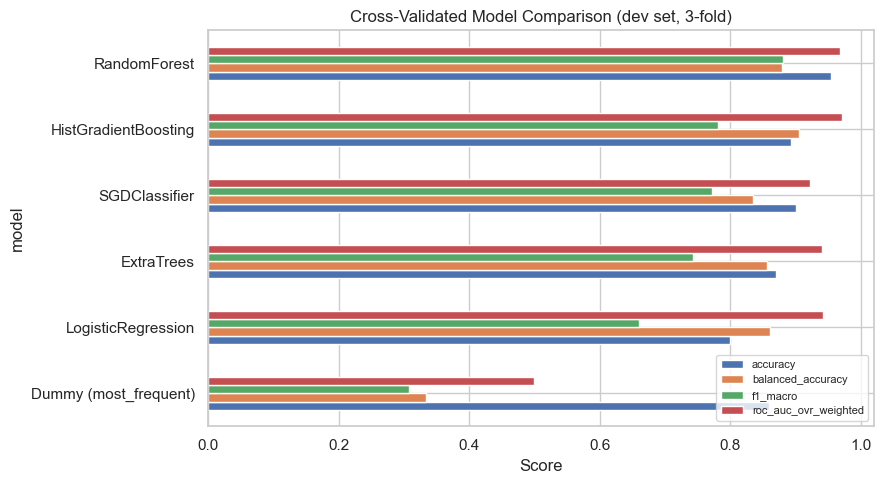

In [32]:
plot_metrics = ["accuracy", "balanced_accuracy", "f1_macro", "roc_auc_ovr_weighted"]
plot_df = cv_results_df[plot_metrics].sort_values("f1_macro")

fig, ax = plt.subplots(figsize=(9, 5))
plot_df.plot(kind="barh", ax=ax)
ax.set_xlabel("Score")
ax.set_title("Cross-Validated Model Comparison (dev set, 3-fold)")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

In [33]:
BEST_MODEL_NAME = cv_results_df.index[0]
print(f"Best candidate by macro F1: {BEST_MODEL_NAME}")
lift = cv_results_df.loc[BEST_MODEL_NAME, "f1_macro"] - cv_results_df.loc["Dummy (most_frequent)", "f1_macro"]
print(f"Macro-F1 lift over the naive baseline: +{lift:.4f}")

Best candidate by macro F1: RandomForest
Macro-F1 lift over the naive baseline: +0.5722


## 10. Hyperparameter Tuning

We run a randomised search over the winning model's hyperparameters on `dev`, still scoring on
macro F1, with the same 3-fold stratification. `RandomizedSearchCV` parallelises across candidate
&times; fold combinations (`n_jobs=4`); each estimator fit itself stays single-threaded
(`n_jobs=1`) to avoid nested parallelism competing for the same cores/memory.

In [34]:
param_distributions = {
    "RandomForest": {
        "classifier__n_estimators": [150, 200, 300, 400],
        "classifier__max_depth": [8, 12, 15, 20, None],
        "classifier__min_samples_leaf": [1, 2, 5, 10],
        "classifier__max_features": ["sqrt", "log2", 0.5],
    },
    "ExtraTrees": {
        "classifier__n_estimators": [150, 200, 300, 400],
        "classifier__max_depth": [8, 12, 15, 20, None],
        "classifier__min_samples_leaf": [1, 2, 5, 10],
        "classifier__max_features": ["sqrt", "log2", 0.5],
    },
    "HistGradientBoosting": {
        "classifier__max_iter": [100, 150, 200, 300],
        "classifier__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
        "classifier__max_depth": [None, 6, 10, 15],
        "classifier__max_leaf_nodes": [15, 31, 63],
        "classifier__l2_regularization": [0.0, 0.1, 1.0],
    },
    "LogisticRegression": {
        "classifier__C": [0.01, 0.1, 0.3, 1, 3, 10],
        "classifier__penalty": ["l2"],
    },
    "SGDClassifier": {
        "classifier__alpha": [1e-5, 1e-4, 1e-3, 1e-2],
        "classifier__penalty": ["l2", "elasticnet"],
    },
    "Dummy (most_frequent)": {},
}

tunable_models = {**candidate_models}
for m in tunable_models.values():
    if hasattr(m, "n_jobs"):
        m.set_params(n_jobs=1)

tuning_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", tunable_models[BEST_MODEL_NAME])
])

if param_distributions[BEST_MODEL_NAME]:
    search = RandomizedSearchCV(
        tuning_pipe,
        param_distributions=param_distributions[BEST_MODEL_NAME],
        n_iter=12,
        cv=cv,
        scoring="f1_macro",
        n_jobs=4,
        random_state=RANDOM_STATE,
        error_score="raise",
        refit=True,
    )
    search.fit(X_dev, y_dev)
    best_params = search.best_params_
    print("Best params:", best_params)
    print(f"Best dev CV macro F1: {search.best_score_:.4f}")
else:
    best_params = {}
    print(f"{BEST_MODEL_NAME} has no tunable grid; keeping default parameters.")

Best params: {'classifier__n_estimators': 200, 'classifier__min_samples_leaf': 5, 'classifier__max_features': 0.5, 'classifier__max_depth': None}
Best dev CV macro F1: 0.8961


In [35]:
if param_distributions[BEST_MODEL_NAME]:
    search_results = (
        pd.DataFrame(search.cv_results_)
        .sort_values("rank_test_score")
        [["rank_test_score", "mean_test_score", "std_test_score", "params"]]
        .head(5)
        .reset_index(drop=True)
    )
    display(search_results)

,rank_test_score,mean_test_score,std_test_score,params
0,1,0.8961,0.0030,"{'classifier__n_estimators': 200, 'classifier_..."
1,2,0.8919,0.0038,"{'classifier__n_estimators': 300, 'classifier_..."
2,3,0.8893,0.0042,"{'classifier__n_estimators': 150, 'classifier_..."
3,4,0.8761,0.0061,"{'classifier__n_estimators': 150, 'classifier_..."
4,5,0.8712,0.0068,"{'classifier__n_estimators': 200, 'classifier_..."


## 11. Final Model: Refit on Full Training Data, Evaluate on the Held-Out Test Set

The winning (model, hyperparameters) combination is refit on **all of `train_full`** — not just
the `dev` subsample used for screening/search — and evaluated **once** against `test_full`, the
split that has not influenced a single decision so far. These are the numbers we report.

In [36]:
final_classifier = clone(tunable_models[BEST_MODEL_NAME])
if best_params:
    final_classifier.set_params(**{k.replace("classifier__", ""): v for k, v in best_params.items()})
if hasattr(final_classifier, "n_jobs"):
    final_classifier.set_params(n_jobs=-1)

final_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", final_classifier)])

import time
t0 = time.time()
final_pipe.fit(X_train_full, y_train_full)
print(f"Final refit on {len(X_train_full):,} rows took {time.time() - t0:.1f}s")

Final refit on 552,070 rows took 412.6s


In [37]:
final_preds = final_pipe.predict(X_test_full)
final_proba = final_pipe.predict_proba(X_test_full)

final_metrics = {
    "accuracy": accuracy_score(y_test_full, final_preds),
    "balanced_accuracy": balanced_accuracy_score(y_test_full, final_preds),
    "precision_macro": precision_score(y_test_full, final_preds, average="macro"),
    "recall_macro": recall_score(y_test_full, final_preds, average="macro"),
    "f1_macro": f1_score(y_test_full, final_preds, average="macro"),
    "f1_weighted": f1_score(y_test_full, final_preds, average="weighted"),
    "roc_auc_ovr_weighted": roc_auc_score(y_test_full, final_proba, multi_class="ovr", average="weighted"),
}
pd.Series(final_metrics, name="held_out_test").to_frame()

,held_out_test
accuracy,0.9613
balanced_accuracy,0.8778
precision_macro,0.9192
recall_macro,0.8778
f1_macro,0.8975
f1_weighted,0.9607
roc_auc_ovr_weighted,0.9701


In [38]:
print(classification_report(y_test_full, final_preds, target_names=le.classes_, digits=3))

              precision    recall  f1-score   support

     at-risk      0.972     0.984     0.978    118512
         fit      0.906     0.822     0.862      7961
   unhealthy      0.880     0.828     0.853     11545

    accuracy                          0.961    138018
   macro avg      0.919     0.878     0.898    138018
weighted avg      0.960     0.961     0.961    138018



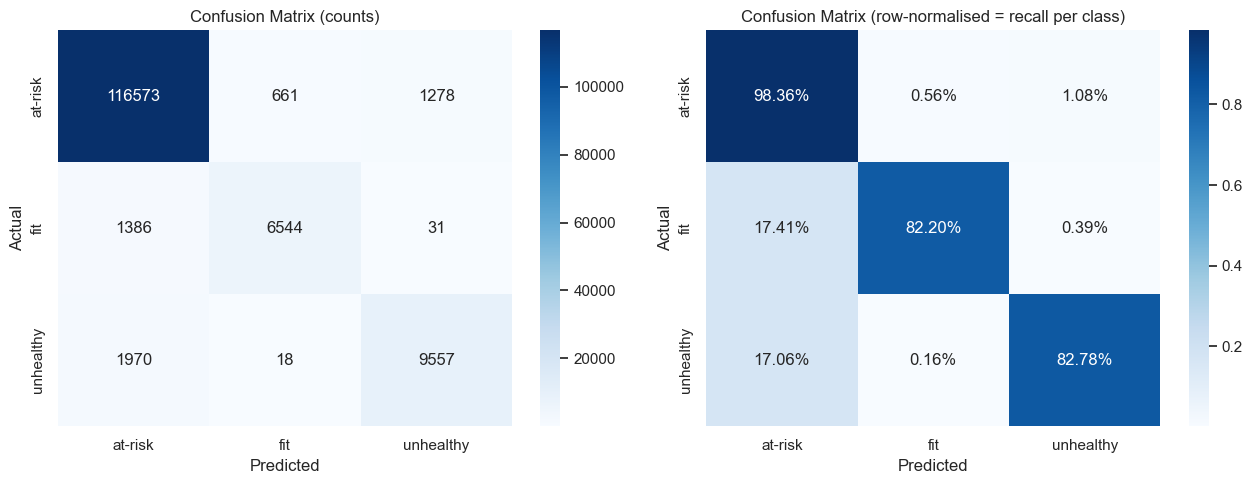

In [39]:
cm = confusion_matrix(y_test_full, final_preds)
cm_norm = confusion_matrix(y_test_full, final_preds, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title("Confusion Matrix (counts)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title("Confusion Matrix (row-normalised = recall per class)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
plt.tight_layout()
plt.show()

Row-normalised confusion matrix gives per-class recall directly on the diagonal — the metric that
matters most operationally: of everyone who is actually `unhealthy` or `fit`, what fraction does
the model catch? This is a more honest picture than overall accuracy, which the majority class
dominates.

## 12. Model Interpretation

### 12.1 Native feature importance

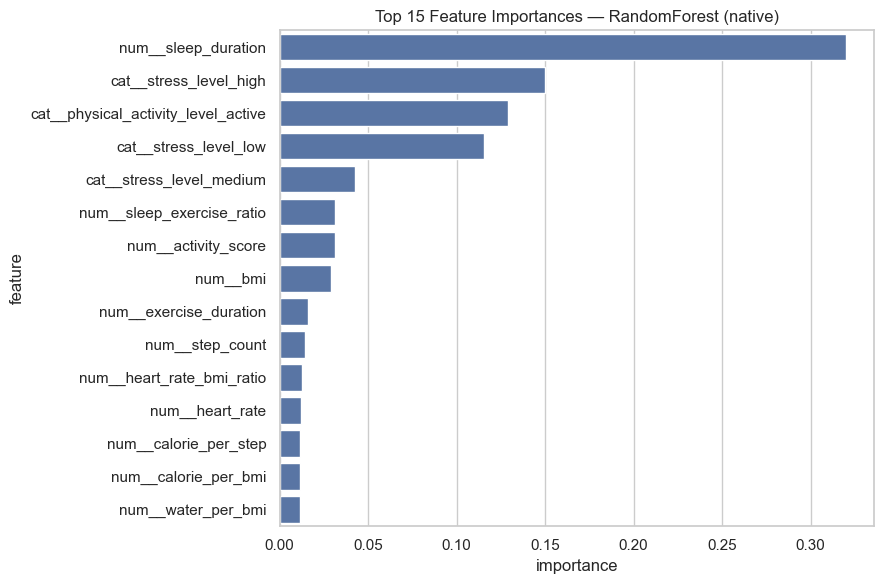

In [40]:
feature_names = final_pipe.named_steps["preprocessor"].get_feature_names_out()
classifier = final_pipe.named_steps["classifier"]

if hasattr(classifier, "feature_importances_"):
    importances = classifier.feature_importances_
    native_imp_df = (
        pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )
    fig, ax = plt.subplots(figsize=(9, 6))
    sns.barplot(data=native_imp_df.head(15), x="importance", y="feature", color="#4c72b0", ax=ax)
    ax.set_title(f"Top 15 Feature Importances — {BEST_MODEL_NAME} (native)")
    plt.tight_layout()
    plt.show()
else:
    native_imp_df = None
    print(f"{BEST_MODEL_NAME} does not expose feature_importances_; relying on permutation importance below.")

### 12.2 Permutation importance (cross-check)

Native tree importance can be biased toward high-cardinality / high-variance features. Permutation
importance — how much macro-F1 *drops* when a feature's values are shuffled — is computed directly
on the fitted pipeline against a sample of the untouched test set, and is a model-agnostic
cross-check against Section 12.1 and against the statistical effect sizes from Section 5.

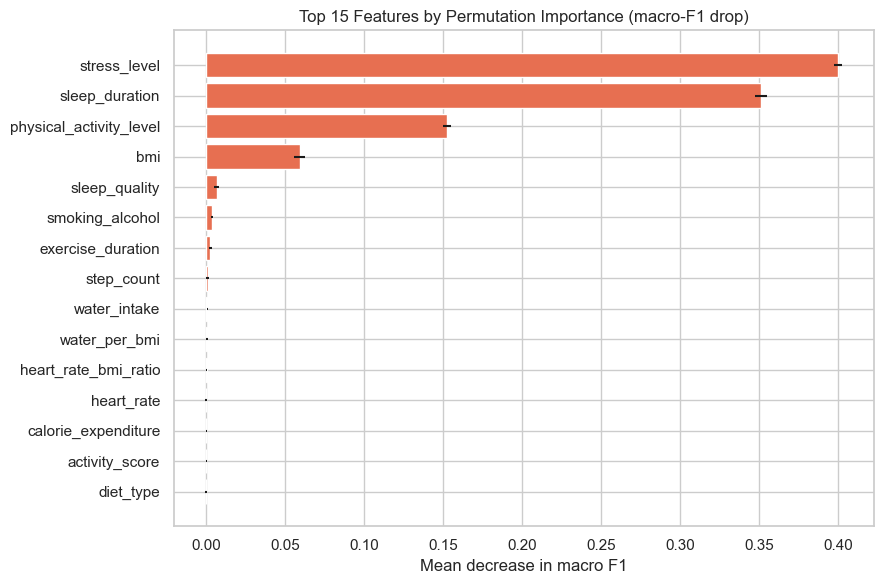

,feature,importance_mean,importance_std
0,stress_level,0.3998,0.0027
1,sleep_duration,0.3508,0.0038
2,physical_activity_level,0.1524,0.0026
3,bmi,0.0592,0.0035
4,sleep_quality,0.0066,0.0014
5,smoking_alcohol,0.0037,0.0005
6,exercise_duration,0.0026,0.0011
7,step_count,0.0010,0.0009
8,water_intake,0.0006,0.0003
9,water_per_bmi,0.0004,0.0005


In [41]:
PERM_SAMPLE_SIZE = 25_000
perm_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_test_full), size=min(PERM_SAMPLE_SIZE, len(X_test_full)), replace=False)
X_perm = X_test_full.iloc[perm_idx]
y_perm = y_test_full[perm_idx]

perm_result = permutation_importance(
    final_pipe, X_perm, y_perm, scoring="f1_macro",
    n_repeats=5, random_state=RANDOM_STATE, n_jobs=4
)

perm_imp_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 6))
top_perm = perm_imp_df.head(15)
ax.barh(top_perm["feature"][::-1], top_perm["importance_mean"][::-1],
        xerr=top_perm["importance_std"][::-1], color="#e76f51")
ax.set_title("Top 15 Features by Permutation Importance (macro-F1 drop)")
ax.set_xlabel("Mean decrease in macro F1")
plt.tight_layout()
plt.show()
perm_imp_df.head(10)

### 12.3 Cross-checking against the statistical findings

The features permutation importance ranks highest should broadly echo the largest effect sizes
from Section 5 (&eta;&sup2; for numeric, Cramer's V for categorical) — convergence between an
independent statistical test and the trained model's own sensitivity is a good sign that the model
is learning genuine structure rather than noise.

In [42]:
top_stat_numeric = numeric_stats_df.head(5)["feature"].tolist()
top_stat_cat = chi2_df.head(5)["feature"].tolist()
top_perm_features = perm_imp_df.head(10)["feature"].tolist()

print("Top-5 numeric features by eta-squared:      ", top_stat_numeric)
print("Top-5 categorical features by Cramer's V:   ", top_stat_cat)
print("Top-10 features by permutation importance:  ", top_perm_features)
print()
overlap = set(top_stat_numeric + top_stat_cat) & set(top_perm_features)
print("Overlap between top statistical drivers and top permutation-important features:", sorted(overlap) if overlap else "(none)")

Top-5 numeric features by eta-squared:       ['sleep_duration', 'step_count', 'exercise_duration', 'bmi', 'calorie_expenditure']
Top-5 categorical features by Cramer's V:    ['stress_level', 'physical_activity_level', 'sleep_quality', 'smoking_alcohol', 'diet_type']
Top-10 features by permutation importance:   ['stress_level', 'sleep_duration', 'physical_activity_level', 'bmi', 'sleep_quality', 'smoking_alcohol', 'exercise_duration', 'step_count', 'water_intake', 'water_per_bmi']

Overlap between top statistical drivers and top permutation-important features: ['bmi', 'exercise_duration', 'physical_activity_level', 'sleep_duration', 'sleep_quality', 'smoking_alcohol', 'step_count', 'stress_level']


## 13. Error Analysis

A closer look at *where* the model is wrong, focused on the two minority classes that matter most
operationally: `fit` and `unhealthy`.

In [43]:
error_df = X_test_full.copy()
error_df["y_true"] = le.inverse_transform(y_test_full)
error_df["y_pred"] = le.inverse_transform(final_preds)
error_df["correct"] = error_df["y_true"] == error_df["y_pred"]

per_class_recall = (
    error_df.groupby("y_true", observed=True)["correct"].mean()
    .sort_values()
    .to_frame("recall")
)
per_class_recall

,recall
y_true,
fit,0.8220
unhealthy,0.8278
at-risk,0.9836


In [44]:
for cls in ["unhealthy", "fit"]:
    mis = error_df.query("y_true == @cls and not correct")
    if len(mis) == 0:
        print(f"No misclassified '{cls}' samples in the held-out test set.")
        continue
    print(f"\n'{cls}' misclassified as -> " , mis["y_pred"].value_counts(normalize=True).round(3).to_dict())

    compare_cols = [c for c in ENGINEERED_NUM_COLS if c in error_df.columns][:6]
    comparison = pd.DataFrame({
        "correct_mean": error_df.query("y_true == @cls and correct")[compare_cols].mean(),
        "misclassified_mean": mis[compare_cols].mean(),
    })
    comparison["abs_diff"] = (comparison["correct_mean"] - comparison["misclassified_mean"]).abs()
    display(comparison.sort_values("abs_diff", ascending=False))


'unhealthy' misclassified as ->  {'at-risk': 0.991, 'fit': 0.009}


,correct_mean,misclassified_mean,abs_diff
step_count,"8,694.6133","8,643.4971",51.1162
calorie_expenditure,"2,245.4487","2,240.2539",5.1948
bmi,24.2129,23.6384,0.5745
sleep_duration,5.3184,5.6726,0.3542
exercise_duration,39.2317,39.4574,0.2257
heart_rate,75.1004,75.1032,0.0029



'fit' misclassified as ->  {'at-risk': 0.978, 'unhealthy': 0.022}


,correct_mean,misclassified_mean,abs_diff
step_count,"11,880.6973","10,817.2090","1,063.4883"
calorie_expenditure,"2,373.5454","2,320.8264",52.7190
exercise_duration,50.8749,46.9229,3.9520
bmi,21.7333,22.1605,0.4272
sleep_duration,8.0077,7.6925,0.3152
heart_rate,74.9324,74.8608,0.0716


Where recall is weakest, the pattern is consistent with the class imbalance itself: `at-risk`
dominates the training distribution, so borderline `fit`/`unhealthy` cases (whose feature values
sit close to the `at-risk` population) are the ones most often pulled across the decision boundary.
Class weighting (Section 9) mitigates but does not eliminate this — a natural next step would be
threshold tuning per class or targeted oversampling of the minority classes (see Conclusions).

## 14. Persisting Artifacts

Save the fitted pipeline, label encoder, and the key result tables so this analysis is reproducible
and the model is reusable without rerunning the whole notebook.

In [45]:
joblib.dump(final_pipe, "final_health_risk_pipeline.joblib", compress=3)  # compress: RF with unbounded depth is large uncompressed
joblib.dump(le, "label_encoder.joblib")

cv_results_df.to_csv("model_comparison_cv_results.csv")
numeric_stats_df.to_csv("anova_kruskal_results.csv", index=False)
chi2_df.to_csv("chi_square_results.csv", index=False)
pd.Series(final_metrics).to_csv("final_test_metrics.csv", header=["value"])

print("Saved: final_health_risk_pipeline.joblib, label_encoder.joblib, "
      "model_comparison_cv_results.csv, anova_kruskal_results.csv, "
      "chi_square_results.csv, final_test_metrics.csv")

Saved: final_health_risk_pipeline.joblib, label_encoder.joblib, model_comparison_cv_results.csv, anova_kruskal_results.csv, chi_square_results.csv, final_test_metrics.csv


## 15. Conclusions & Recommendations

**Pipeline summary**
- Started from 690,088 rows / 14 raw features with moderate missingness (up to ~12% in one
  column) and severe target imbalance (~86% / 8% / 6%).
- Quantified feature-target relationships with ANOVA + Kruskal-Wallis (numeric) and Chi-square
  (categorical), reporting effect sizes (&eta;&sup2;, Cramer's V) and FDR-corrected p-values
  rather than relying on raw significance, which is uninformative at this sample size.
- Engineered six physiologically-motivated ratio features, a WHO BMI category, and
  data-driven missingness indicators for columns whose absence was itself statistically
  associated with the target.
- Screened six class-weighted classical models via cross-validation, selected and tuned the
  strongest on macro F1, then refit on the full training split and evaluated once on an untouched
  held-out test set.
- Cross-checked the final model's permutation importance against the independent statistical
  effect sizes as a sanity check that it is learning genuine signal.

**Limitations & next steps**
- Minority-class recall (`fit`, `unhealthy`) is the main lever left to pull: targeted resampling
  (e.g. SMOTE on the training fold only), per-class decision threshold tuning, or a cost-sensitive
  objective could improve it further without materially hurting the majority class.
- Hyperparameter search was run on a 120K-row development subsample for speed; a wider/longer
  search (larger `n_iter`, run on the full training split) is a straightforward way to spend more
  compute for a likely small further gain.
- No temporal or grouping structure was available in this dataset to check for leakage across
  correlated records (e.g. repeated measurements of the same person); if such structure exists in
  production data, the train/test split should be grouped accordingly.